In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import map_feature,sigmoid,plot_decision_boundary
import math
import copy

**Reading the datas**

In [2]:
df = pd.read_csv('data/microchip.txt',header=None,names=['f1','f2','quality'])
df

,f1,f2,quality
0,0.051267,0.699560,1
1,-0.092742,0.684940,1
2,-0.213710,0.692250,1
3,-0.375000,0.502190,1
4,-0.513250,0.465640,1
...,...,...,...
113,-0.720620,0.538740,0
114,-0.593890,0.494880,0
115,-0.484450,0.999270,0
116,-0.006336,0.999270,0


**Here f1 and f2 are the features of the micro chips and quality represents 1 and 2 , 1 means the chip is accepted for selling and 0 means the chip is not accepted for selling**

In [3]:
X_train = np.array(df[['f1','f2']])
Y_train = np.array(df['quality'])
print(f'The first five training examples are {X_train[:5]} and {Y_train[:5]}')

The first five training examples are [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]] and [1 1 1 1 1]


**Creating the masking**

In [4]:
pos = Y_train == 1  #pos means the chip was accepted
neg = Y_train == 0  #neg means the chip wasnot accepted

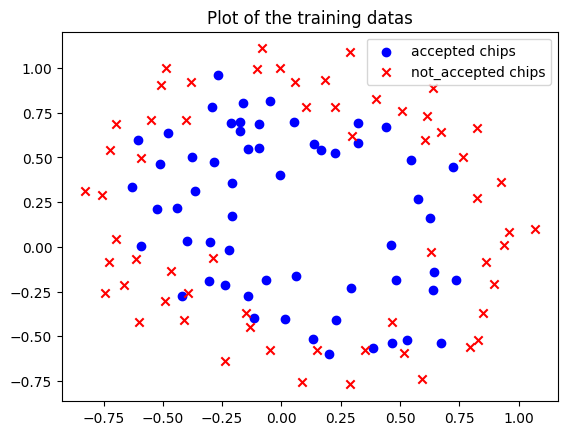

In [5]:
plt.scatter(X_train[pos,0],X_train[pos,1],marker='o',c='b',label='accepted chips')
plt.scatter(X_train[neg,0],X_train[neg,1],marker='x',c='r',label='not_accepted chips')
plt.title('Plot of the training datas')
plt.legend()
plt.show()

**here we are visualizing the data to study the complexity of pattern, and as we can see from the plot above that the pattern or the datas cannot be classified with the help of linear logistic model, so we must increase the complexity of the model , through feature engineering**

In [6]:
mapped_X = map_feature(X_train[:,0],X_train[:,1])  #feature engineering to make the features polynomial so that our model can generalize
mapped_X
m,n = mapped_X.shape
mapped_X
print(mapped_X.shape)

(118, 27)


**Cost function with regularization to prevent the overfitting of the model, as we have used the polynomial function or feature engineering to solve the complex pattern**

In [7]:
def cost_function(x,y,w,b,lambda_):
    m,n = x.shape
    cost = 0
    for i in range(m):
        y_pred = sigmoid(np.dot(x[i],w) + b)
        cost+= (- y[i] * np.log(y_pred)) - (1-y[i]) * np.log(1 - y_pred)
    cost = cost / m
    reg_cost = 0
    for j in range(n):
        reg_cost+=np.square(w[j])
    reg_cost = reg_cost * (lambda_/(2*m))
    total_cost = cost + reg_cost
    return total_cost
w_init = np.zeros(n)
b_init = 0
lambda_ = 0.7
print(f'The initial cost function is:', cost_function(mapped_X,Y_train,w_init,b_init,lambda_))
        

The initial cost function is: 0.6931471805599461


**Partial Derivative**

In [8]:
def gradient(x,y,w,b,lambda_):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        y_pred = sigmoid(np.dot(x[i],w) + b)
        error = y_pred - y[i]
        dj_db+=error
        for j in range(n):
            dj_dw[j]+=error * x[i,j]
    dj_dw,dj_db = dj_dw/m,dj_db/m        
    for j in range(n):  #we only do the regularization on the weights of the model not the bias, as doing regularization on bias has very very small impact while training the model
        dj_dw[j] += (lambda_/m) * w[j]
    return dj_dw,dj_db
    
        

**Fitting the model**

In [9]:
def gradient_descent(x,y,w_init,b_init,gradient,cost_function,lambda_,alpha,iterations):
    w = copy.deepcopy(w_init)
    b = b_init
    cost_hist = []
    iter_hist = []
    for i in range(iterations):
        dj_dw,dj_db = gradient(x,y,w,b,lambda_) 
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)
        cost = cost_function(x,y,w,b,lambda_)
        if i % math.ceil(iterations/10) == 0:
            cost_hist.append(cost)
            iter_hist.append(i)
    return w,b,cost_hist,iter_hist
lambda_ = 0.01    

# Some gradient descent settings
iterations = 10000
alpha = 0.01    
final_w,final_b,cost_hist,iter_hist = gradient_descent(mapped_X,Y_train,w_init,b_init,gradient,cost_function,lambda_,alpha,iterations)  
print(f'The final weight and the bias of our logistic regression model are {final_w} and {final_b} respectively')
print(final_w.shape)


The final weight and the bias of our logistic regression model are [ 6.96671928e-01  1.35773608e+00 -2.16201833e+00 -9.25071996e-01
 -1.30872060e+00  1.01082577e-01 -3.87456890e-01 -3.74132124e-01
 -2.31548072e-01 -1.65611363e+00 -9.06127484e-02 -6.52617637e-01
 -2.70105719e-01 -1.33148829e+00 -3.13257582e-01 -2.37874237e-01
 -7.47228535e-02 -2.95040764e-01 -2.98323425e-01 -6.57596207e-01
 -1.22070520e+00 -1.71332553e-03 -3.22236673e-01 -1.47192372e-03
 -3.55748754e-01 -1.36513097e-01 -1.17870213e+00] and 1.3048331648844416 respectively
(27,)


**Plotting the learning curve**

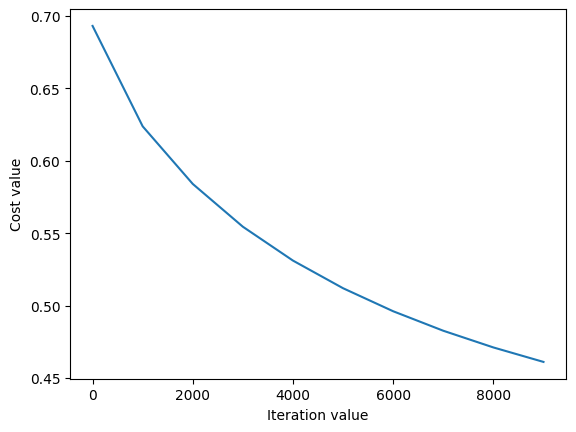

In [10]:
plt.plot(iter_hist,cost_hist)
plt.xlabel('Iteration value')
plt.ylabel('Cost value')
plt.show()

**Plot of our logistic model**

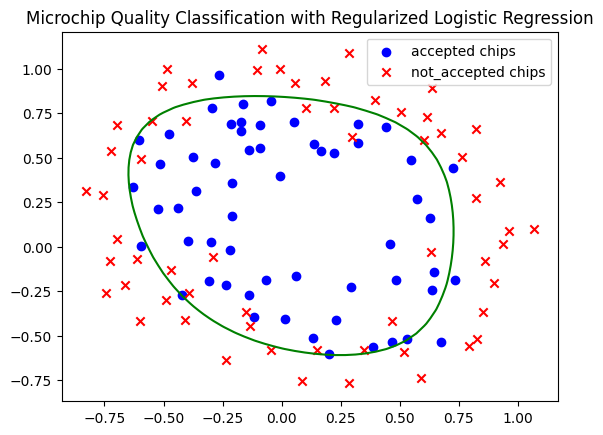

In [25]:
#training datas
plt.scatter(X_train[pos,0],X_train[pos,1],marker='o',c='b',label='accepted chips')
plt.scatter(X_train[neg,0],X_train[neg,1],marker='x',c='r',label='not_accepted chips')

#decision boundary
plot_decision_boundary(final_w, final_b, mapped_X, Y_train)
plt.title('Microchip Quality Classification with Regularized Logistic Regression')
plt.legend()
plt.show()

**Making classification**

In [19]:
def classify(x,y,w,b):
    m,n = x.shape
    p=np.zeros(m)
    for i in range(m):
        y_pred = sigmoid(np.dot(x[i],w) + b)
        if y_pred>=0.5:   #here 0.5 is the decision threshold
            p[i] = 1
        else:
            p[i] = 0
    return p
classification = classify(mapped_X,Y_train,final_w,final_b)    
    
    

**Checking the accuracy**

In [23]:
print(f'The accuracy of our trained logistic model is {(np.mean(classification==Y_train) * 100):.2f}')


The accuracy of our trained logistic model is 83.05


**So we can observe that our tained logistic model is 83% accurate**